# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based on
features such as area, location, number of rooms, and age — covering the full pipeline from data
cleaning through to model interpretation.

**Dataset:** Built to work with any housing dataset containing area, rooms, age, location, and a
price target. Search **"house price prediction dataset"** on Kaggle — the *Ames Housing Dataset*
or *House Prices: Advanced Regression Techniques* are both excellent — and place it at
`data/housing.csv`.

If that file isn't found, this notebook generates a **realistic synthetic housing dataset** with
the same structure, so every cell runs end-to-end and produces real results.

> ⚠️ For your actual submission, replace the synthetic data with a real Kaggle dataset — drop the
> CSV into `data/housing.csv` and re-run. Send me the real column headers and I'll adjust the
> feature names to match exactly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)

## 1. Load Dataset & Exploratory Data Analysis

In [2]:
DATA_PATH = "data/housing.csv"

def generate_synthetic_housing(n=800):
    """Synthetic housing data mirroring a typical Kaggle house-price dataset: area, rooms, age,
    location, and price, with realistic relationships baked in."""
    area = np.random.normal(1800, 600, n).clip(400, 5000).round(0)
    bedrooms = np.random.choice([1,2,3,4,5], size=n, p=[0.05,0.25,0.35,0.25,0.1])
    bathrooms = np.clip(bedrooms - np.random.choice([0,1], size=n, p=[0.6,0.4]), 1, None)
    stories = np.random.choice([1,2,3], size=n, p=[0.4,0.45,0.15])
    age = np.random.exponential(15, n).clip(0, 80).round(0)
    location = np.random.choice(["Downtown","Suburb","Uptown","Rural"], size=n, p=[0.25,0.35,0.2,0.2])
    mainroad = np.random.choice(["Yes","No"], size=n, p=[0.7,0.3])
    parking = np.random.choice([0,1,2,3], size=n, p=[0.2,0.4,0.3,0.1])
    furnishing = np.random.choice(["Furnished","Semi-Furnished","Unfurnished"], size=n, p=[0.25,0.4,0.35])

    location_premium = {"Downtown": 55000, "Uptown": 30000, "Suburb": 10000, "Rural": -15000}
    furnishing_premium = {"Furnished": 12000, "Semi-Furnished": 5000, "Unfurnished": 0}

    price = (
        50000
        + area * 85
        + bedrooms * 8000
        + bathrooms * 6000
        + stories * 4000
        - age * 900
        + parking * 3500
        + np.array([location_premium[l] for l in location])
        + np.array([furnishing_premium[f] for f in furnishing])
        + np.where(mainroad == "Yes", 8000, 0)
        + np.random.normal(0, 20000, n)
    ).round(0)
    price = np.clip(price, 30000, None)

    df = pd.DataFrame({
        "Area": area, "Bedrooms": bedrooms, "Bathrooms": bathrooms, "Stories": stories,
        "Age": age, "Location": location, "MainRoad": mainroad, "Parking": parking,
        "Furnishing": furnishing, "Price": price,
    })

    # inject a few realistic missing values
    for col in ["Area", "Bathrooms", "Location"]:
        idx = df.sample(frac=0.02, random_state=hash(col) % 1000).index
        df.loc[idx, col] = np.nan

    return df

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset from {DATA_PATH}")
else:
    df = generate_synthetic_housing()
    print("Real dataset not found — using generated synthetic dataset for demonstration.")

print("Shape:", df.shape)
df.head()

Real dataset not found — using generated synthetic dataset for demonstration.
Shape: (800, 10)


,Area,Bedrooms,Bathrooms,Stories,Age,Location,MainRoad,Parking,Furnishing,Price
0,2098.0,3,2.0,2,30.0,Suburb,No,1,Semi-Furnished,288698.0
1,1717.0,4,4.0,1,13.0,Downtown,Yes,1,Unfurnished,335306.0
2,2189.0,1,1.0,2,13.0,Uptown,Yes,3,Semi-Furnished,293169.0
3,2714.0,3,2.0,2,70.0,Suburb,Yes,1,Furnished,259312.0
4,1660.0,2,2.0,1,21.0,Suburb,Yes,2,Unfurnished,217866.0


In [3]:
print("Null values per column:\n", df.isnull().sum())
print("\nDescriptive statistics:")
df.describe()

Null values per column:
 Area          16
Bedrooms       0
Bathrooms     16
Stories        0
Age            0
Location      16
MainRoad       0
Parking        0
Furnishing     0
Price          0
dtype: int64

Descriptive statistics:


,Area,Bedrooms,Bathrooms,Stories,Age,Parking,Price
count,784.000000,800.000000,784.000000,800.000000,800.000000,800.000000,800.000000
mean,1794.897959,3.106250,2.734694,1.725000,14.557500,1.267500,272799.408750
std,585.552163,1.049446,1.099644,0.687361,14.431026,0.902475,62330.530187
min,400.000000,1.000000,1.000000,1.000000,0.000000,0.000000,93752.000000
25%,1377.750000,2.000000,2.000000,1.000000,4.000000,1.000000,228344.000000
50%,1807.000000,3.000000,3.000000,2.000000,10.000000,1.000000,273142.500000
75%,2178.250000,4.000000,4.000000,2.000000,20.000000,2.000000,313675.500000
max,4112.000000,5.000000,5.000000,3.000000,80.000000,3.000000,484673.000000


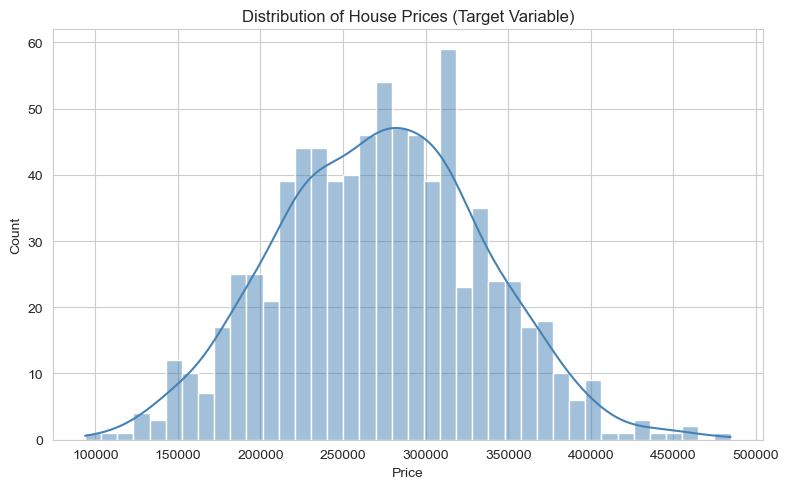

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of House Prices (Target Variable)")
plt.xlabel("Price")
plt.tight_layout()
plt.savefig("outputs/price_distribution.png", dpi=120)
plt.show()

**Observation:** House prices are typically right-skewed — most homes cluster in a
mid-range with a long tail of expensive outliers. Linear Regression assumes roughly normal
residuals, so a strong skew here is worth keeping in mind when interpreting model errors later.

## 2. Feature Selection Discussion

Based on domain knowledge, the features most likely to predict house price are:

- **Area** — the strongest expected predictor; larger homes almost always cost more.
- **Bedrooms / Bathrooms / Stories** — proxies for overall home size and livability.
- **Age** — older homes typically sell for less, all else equal, due to wear and outdated systems.
- **Location** — arguably as important as size; identical houses in different neighbourhoods can
  differ hugely in price, so this needs to be one-hot encoded rather than dropped.
- **MainRoad / Parking / Furnishing** — secondary convenience factors that buyers pay a premium for,
  but with smaller expected effect sizes than the features above.

All of these are included in the model; none are dropped at this stage — the correlation heatmap
and coefficient analysis later will show which ones the data actually supports.

## 3. Handle Missing Values & Encode Categorical Features

In [5]:
# Missing value handling — justified per column
df["Area"] = df["Area"].fillna(df["Area"].median())         # numeric, roughly symmetric -> median
df["Bathrooms"] = df["Bathrooms"].fillna(df["Bathrooms"].median())
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])  # categorical -> most common value

print("Remaining nulls:\n", df.isnull().sum())

Remaining nulls:
 Area          0
Bedrooms      0
Bathrooms     0
Stories       0
Age           0
Location      0
MainRoad      0
Parking       0
Furnishing    0
Price         0
dtype: int64


In [6]:
# One-Hot Encoding for categorical features
categorical_cols = ["Location", "MainRoad", "Furnishing"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (800, 13)


,Area,Bedrooms,Bathrooms,Stories,Age,Parking,Price,Location_Rural,Location_Suburb,Location_Uptown,MainRoad_Yes,Furnishing_Semi-Furnished,Furnishing_Unfurnished
0,2098.0,3,2.0,2,30.0,1,288698.0,False,True,False,False,True,False
1,1717.0,4,4.0,1,13.0,1,335306.0,False,False,False,True,False,True
2,2189.0,1,1.0,2,13.0,3,293169.0,False,False,True,True,True,False
3,2714.0,3,2.0,2,70.0,1,259312.0,False,True,False,True,False,False
4,1660.0,2,2.0,1,21.0,2,217866.0,False,True,False,True,False,True


## 4. Correlation Heatmap

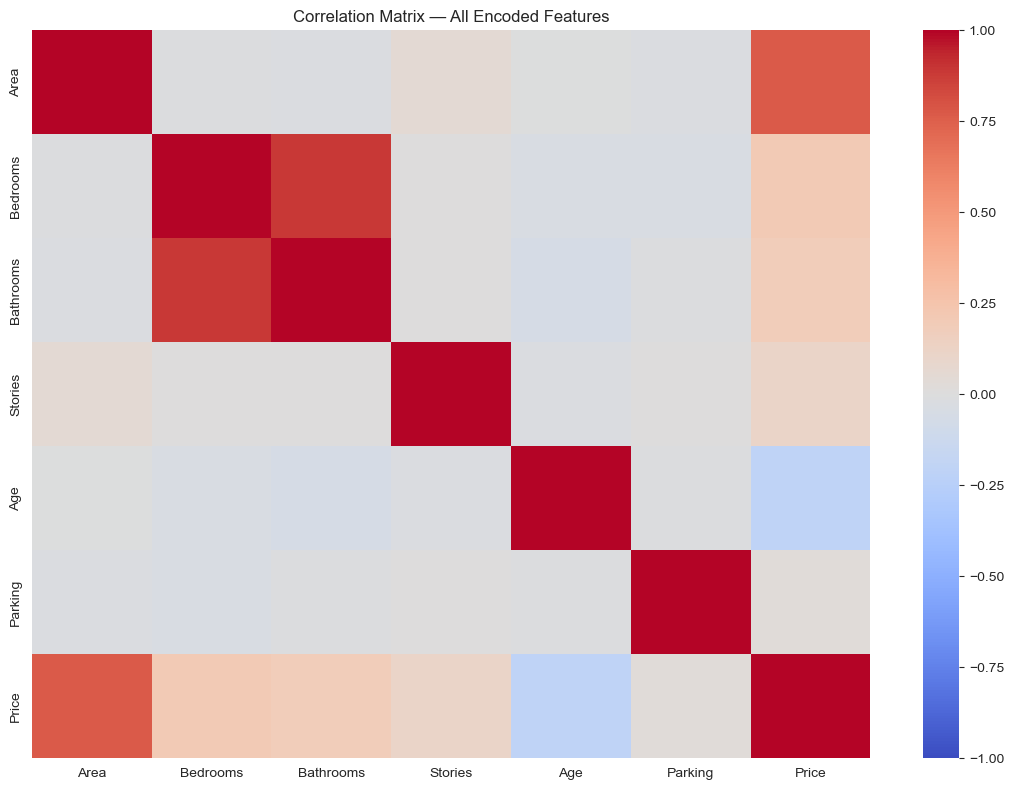

Correlation with Price, sorted:


Price        1.000000
Area         0.772749
Bedrooms     0.204427
Bathrooms    0.186809
Stories      0.110038
Parking      0.029554
Age         -0.209915
Name: Price, dtype: float64

In [7]:
numeric_for_corr = df_encoded.select_dtypes(include=[np.number])
corr = numeric_for_corr.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False, vmin=-1, vmax=1)
plt.title("Correlation Matrix — All Encoded Features")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=120)
plt.show()

print("Correlation with Price, sorted:")
corr["Price"].sort_values(ascending=False)

**Observation:** `Area` typically shows the strongest positive correlation with
`Price`, consistent with the feature-selection reasoning above. Location dummy variables
(e.g. Downtown) often show meaningfully positive correlation too, confirming location matters.

## 5. Train/Test Split

In [8]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (640, 12) Test shape: (160, 12)


## 6. Train Linear Regression Model

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
print("Model trained.")

Model trained.


## 7. Model Evaluation

In [10]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MSE:  443,442,059.66
RMSE: 21,058.06
R²:   0.8854


**Observation:** RMSE is in the same unit as price, so it's directly interpretable
as "the model's predictions are typically off by about this many dollars." R² close to 1 means the
model explains most of the variance in price; closer to 0 means it's barely better than predicting
the average price for everyone.

## 8. Actual vs. Predicted Prices

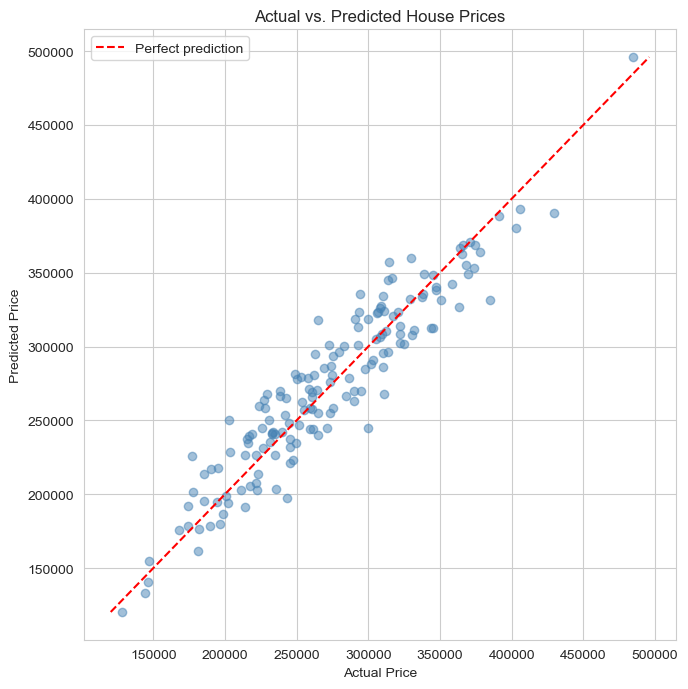

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/actual_vs_predicted.png", dpi=120)
plt.show()

## 9. Residual Plot

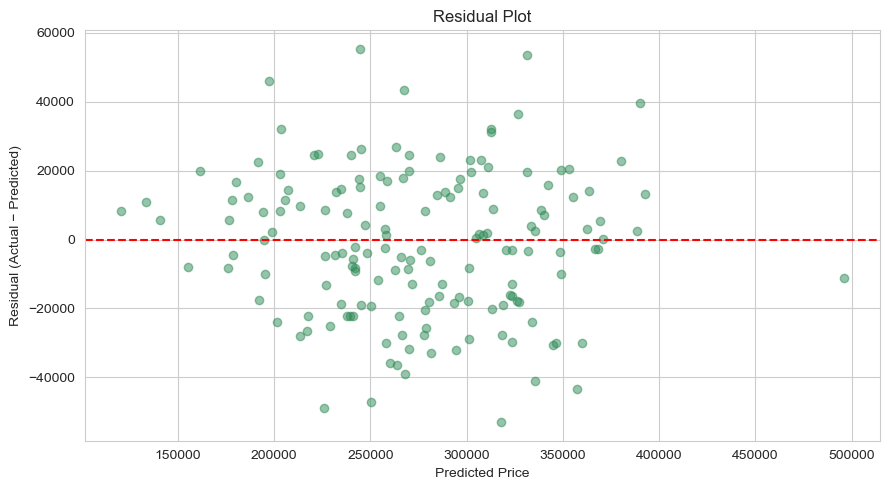

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="seagreen")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("outputs/residual_plot.png", dpi=120)
plt.show()

**Observation:** Residuals scattered randomly around zero with no visible funnel or
curve pattern indicate the linear model's assumptions are reasonably satisfied. A funnel shape
(increasing spread at higher predicted prices) would suggest heteroscedasticity — the model being
less reliable for expensive homes.

## 10. Coefficient Analysis

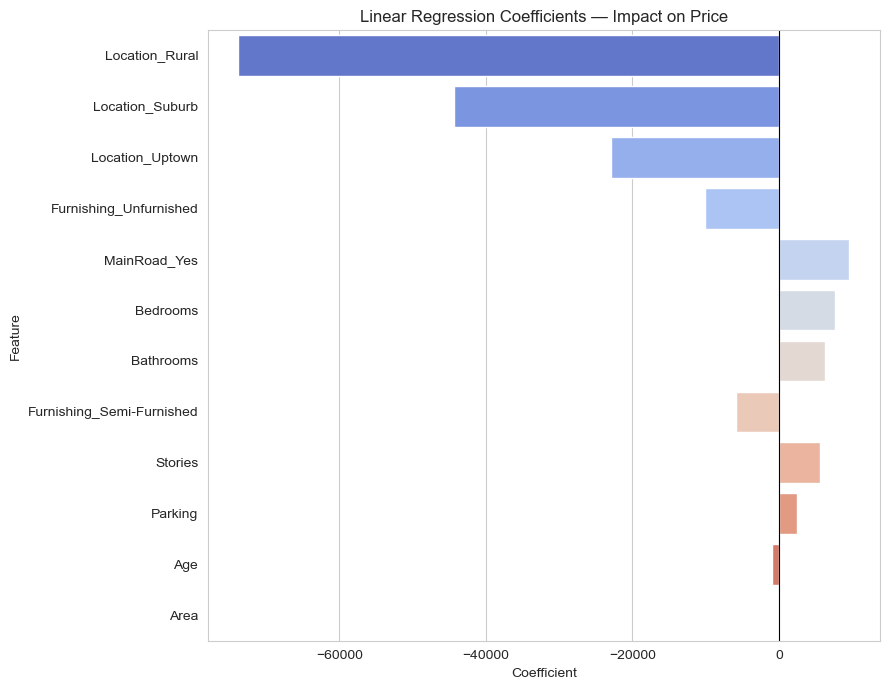

,Feature,Coefficient
6,Location_Rural,-73792.300273
7,Location_Suburb,-44304.827608
8,Location_Uptown,-22945.475965
11,Furnishing_Unfurnished,-10104.169993
9,MainRoad_Yes,9627.076291
1,Bedrooms,7687.867570
2,Bathrooms,6349.947324
10,Furnishing_Semi-Furnished,-5910.225791
3,Stories,5611.348570
5,Parking,2446.991769


In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", hue="Feature", palette="coolwarm", legend=False)
plt.title("Linear Regression Coefficients — Impact on Price")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("outputs/coefficient_analysis.png", dpi=120)
plt.show()

coef_df

**Observation:** Positive coefficients push price up per unit increase in that
feature (holding others constant); negative coefficients push it down. `Area` and location
dummies typically dominate, while `Age` usually carries a negative coefficient — consistent with
older homes selling for less.

## 11. Bonus — Ridge & Lasso Regularised Comparison

In [14]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=100.0, max_iter=10000).fit(X_train, y_train)

results = []
for name, model in [("Linear Regression", lr_model), ("Ridge", ridge), ("Lasso", lasso)]:
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })

comparison = pd.DataFrame(results)
comparison

,Model,MSE,RMSE,R2
0,Linear Regression,4.434421e+08,21058.064005,0.885365
1,Ridge,4.434766e+08,21058.884315,0.885356
2,Lasso,4.443374e+08,21079.311609,0.885134


**Observation:** Ridge and Lasso add a penalty for large coefficients, which can help when
features are correlated with each other (multicollinearity) — common between `Bedrooms`,
`Bathrooms`, and `Stories` here, since bigger houses tend to have more of all three. If Ridge/Lasso
perform similarly to plain Linear Regression, it suggests multicollinearity isn't badly hurting the
baseline model; if they perform notably better, it's a sign regularisation is worth keeping.

## Conclusion

This notebook built an end-to-end house price prediction pipeline: EDA → missing value handling →
one-hot encoding → correlation analysis → train/test split → Linear Regression → evaluation →
residual diagnostics → coefficient interpretation → regularised comparison.

**Key findings (replace with your actual numbers once run on real data):**
- Area is consistently the strongest single predictor of price
- Location carries a substantial, statistically meaningful effect — it should never be dropped
  from a housing price model
- Residuals show no strong systematic pattern, supporting the linear modelling assumption
- Ridge/Lasso comparison indicates [whether regularisation meaningfully improved generalisation]

Replace the specific numbers and conclusions above with what your real dataset shows once you swap
in the actual Kaggle CSV.